<center><img src="img/banner.jpeg" width=1200px /></center>

<center><h1><b><span style="color: green">Translational Neuroscience School 2026</b></span></h1></center>
    
# Python desde cero: Lo necesario para hacer calcular la pendiente y hacer gráficos

Este notebook enseña los fundamentos de Python que necesitas para entender y modificar código como este:

```python
def calculate_slope(trace, sr=16000, samp_window=10):
    dt = 1.0 / sr
    dtrace = np.gradient(trace, dt)
    peak_ix = np.argmin(dtrace)
    left = peak_ix - samp_window
    right = peak_ix + samp_window
    x_fit = np.arange(left, right)
    y_fit = trace[left:right]
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    return slope * sr
```

No se cubrira todo Python, solo lo que se necesita para calcular la pendiente y hacer gráficos sencillos. Cada concepto se presenta porque aparece en el código real.

---

## 1. Variables: guardar valores con un nombre

Una variable es un nombre que apunta a un valor. Se crea con `=`.

In [1]:
# Números enteros (int)
sr = 16000
samp_window = 10

# Números decimales (float)
dt = 1.0 / sr

# Texto (string)
group = 'shocked'
phase = 'pre'

# Booleanos (True / False)
wo_stim_art = True

print("sr =", sr)
print("dt =", dt)
print("group =", group)
print("wo_stim_art =", wo_stim_art)

sr = 16000
dt = 6.25e-05
group = shocked
wo_stim_art = True


In [2]:
# type() te dice qué tipo es cada variable
print(type(sr))           # int
print(type(dt))           # float
print(type(group))        # str
print(type(wo_stim_art))  # bool

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>


¿Dónde aparece esto en nuestro código?

```python
def calculate_slope(trace, sr=16000, samp_window=10):
    dt = 1.0 / sr          # ← variable float
    ...
    left = peak_ix - samp_window   # ← variable int
```

---

## 2. Operaciones matemáticas básicas

In [3]:
a = 16000
b = 10

print("Suma:", a + b)
print("Resta:", a - b)
print("Multiplicación:", a * b)
print("División:", a / b)           # siempre da float
print("División entera:", a // b)   # descarta decimales
print("Potencia:", 2 ** 10)

sr = 16000
dt = 1.0 / sr
print(f"\ndt = 1/{sr} = {dt} segundos")
print(f"dt = {dt * 1000} ms")
print(f"dt = {dt * 1e6} µs")

Suma: 16010
Resta: 15990
Multiplicación: 160000
División: 1600.0
División entera: 1600
Potencia: 1024

dt = 1/16000 = 6.25e-05 segundos
dt = 0.0625 ms
dt = 62.5 µs


### f-strings: texto con variables dentro

La `f` antes de las comillas permite insertar variables con `{}`.

In [4]:
nombre = "fEPSP"
slope = -45.23
n_muestras = 384

# Sin f-string (incómodo)
print("El " + nombre + " tiene slope " + str(slope))

# Con f-string (mucho mejor)
print(f"El {nombre} tiene slope {slope}")
print(f"La traza tiene {n_muestras} muestras")
print(f"Slope redondeado: {slope:.1f} V/s")   # :.1f = 1 decimal

El fEPSP tiene slope -45.23
El fEPSP tiene slope -45.23
La traza tiene 384 muestras
Slope redondeado: -45.2 V/s


---

## 3. Listas: colecciones ordenadas de valores

Una lista guarda varios valores en orden. Se crea con `[]`.

In [5]:
valores = [10, 20, 30, 40, 50]
print("Lista:", valores)
print("Longitud:", len(valores))

Lista: [10, 20, 30, 40, 50]
Longitud: 5


In [6]:
# Acceder por índice (empieza en 0, no en 1)
print("Primer elemento:  valores[0] =", valores[0])
print("Segundo elemento: valores[1] =", valores[1])
print("Último elemento:  valores[-1] =", valores[-1])

Primer elemento:  valores[0] = 10
Segundo elemento: valores[1] = 20
Último elemento:  valores[-1] = 50


In [7]:
# Slicing: extraer un pedazo de la lista
print("Del índice 1 al 3:", valores[1:3])    # incluye 1, excluye 3
print("Los primeros 3:", valores[:3])         # desde el inicio
print("Desde el 2 hasta el final:", valores[2:])

Del índice 1 al 3: [20, 30]
Los primeros 3: [10, 20, 30]
Desde el 2 hasta el final: [30, 40, 50]


¿Dónde aparece esto?

```python
y_fit = trace[left:right]    # ← slicing para extraer la ventana
```

---

## 4. Arrays de NumPy: listas optimizadas para números

Las listas de Python son lentas para cálculos numéricos. NumPy proporciona **arrays**: como listas pero mucho más rápidos y con operaciones matemáticas incorporadas.

In [8]:
import numpy as np

a = np.array([1, 2, 3, 4, 5])
print("Array:", a)
print("Tipo:", type(a))

Array: [1 2 3 4 5]
Tipo: <class 'numpy.ndarray'>


In [9]:
# Diferencia clave: las operaciones se aplican a TODOS los elementos
array = np.array([1, 2, 3, 4, 5])

print("* 2:", array * 2)        # [2, 4, 6, 8, 10]
print("+ 10:", array + 10)      # [11, 12, 13, 14, 15]
print("* 1000:", array * 1000)   # [1000, 2000, 3000, 4000, 5000]

* 2: [ 2  4  6  8 10]
+ 10: [11 12 13 14 15]
* 1000: [1000 2000 3000 4000 5000]


¿Dónde aparece?

```python
trace = trace * 1000    # ← convierte de V a mV, multiplica CADA punto
x = dt * np.arange(len(trace))  # ← convierte muestras a segundos
x = x * 1000            # ← convierte segundos a ms
```

In [10]:
# Funciones útiles de NumPy

# np.arange: secuencia de números
print("arange(5):", np.arange(5))           # [0, 1, 2, 3, 4]
print("arange(2, 7):", np.arange(2, 7))     # [2, 3, 4, 5, 6]

# np.argmin / np.argmax: ÍNDICE del mínimo/máximo
datos = np.array([5, 3, 8, 1, 9, 2])
print(f"\nDatos: {datos}")
print(f"Mínimo: {np.min(datos)} en índice {np.argmin(datos)}")
print(f"Máximo: {np.max(datos)} en índice {np.argmax(datos)}")

arange(5): [0 1 2 3 4]
arange(2, 7): [2 3 4 5 6]

Datos: [5 3 8 1 9 2]
Mínimo: 1 en índice 3
Máximo: 9 en índice 4


¿Dónde aparece?

```python
peak_ix = np.argmin(dtrace)     # ← índice donde la derivada es más negativa
x_fit = np.arange(left, right)  # ← secuencia de índices para la ventana
```

In [11]:
# Slicing funciona igual que con listas
traza = np.array([0.1, 0.2, -0.5, -1.2, -0.8, -0.3, 0.0, 0.2])
print("Traza completa:", traza)
print("Elementos 2 a 5:", traza[2:5])

# Además: indexar con condiciones (boolean indexing)
print("\nElementos negativos:", traza[traza < 0])
print("Máscara:", traza < 0)

Traza completa: [ 0.1  0.2 -0.5 -1.2 -0.8 -0.3  0.   0.2]
Elementos 2 a 5: [-0.5 -1.2 -0.8]

Elementos negativos: [-0.5 -1.2 -0.8 -0.3]
Máscara: [False False  True  True  True  True False False]


¿Dónde aparece?

```python
trace = trace[rel_t - offset > 0]    # ← filtra con condición booleana
```

---

## 5. Condicionales: tomar decisiones con `if`

In [12]:
mouse_n = 25
group = 'shocked'

if group == 'shocked' and mouse_n >= 24:
    print(f"Error: ratón {mouse_n} no disponible para shocked (máx 23)")

if group == 'control' and mouse_n >= 12:
    print(f"Error: ratón {mouse_n} no disponible para control (máx 11)")

Error: ratón 25 no disponible para shocked (máx 23)


In [13]:
# Operadores de comparación
a = 10
print(f"a == 10: {a == 10}")   # igual
print(f"a != 5:  {a != 5}")    # distinto
print(f"a > 5:   {a > 5}")     # mayor
print(f"a >= 10: {a >= 10}")   # mayor o igual

# Combinar con and / or
print(f"\na > 5 and a < 20: {a > 5 and a < 20}")
print(f"a > 50 or a < 20: {a > 50 or a < 20}")

a == 10: True
a != 5:  True
a > 5:   True
a >= 10: True

a > 5 and a < 20: True
a > 50 or a < 20: True


In [14]:
# if / elif / else
valor = -3

if valor > 0:
    print("Positivo")
elif valor == 0:
    print("Cero")
else:
    print("Negativo")

Negativo


¿Dónde aparece?

```python
if group == 'shocked' and mouse_n >= 24:
    print('Error...')
    return None                    # ← sale de la función

if isinstance(chan, dict):         # ← verifica el tipo de dato
    ...
```

---

## 6. Bucles `for`: repetir acciones

In [15]:
for i in range(5):
    print(f"Iteración {i}")

Iteración 0
Iteración 1
Iteración 2
Iteración 3
Iteración 4


In [16]:
fases = ['pre', 'post']
for fase in fases:
    print(f"Procesando fase: {fase}")

Procesando fase: pre
Procesando fase: post


In [17]:
datos = [10, 20, 30, 40]
for i in range(len(datos)):
    print(f"Índice {i} → valor {datos[i]}")

Índice 0 → valor 10
Índice 1 → valor 20
Índice 2 → valor 30
Índice 3 → valor 40


¿Dónde aparece?

```python
for i in range(d):                    # ← aplica la derivada d veces
    dtrace = np.gradient(dtrace, dt)

for pulse in range(n_pulses):         # ← procesa cada pulso
    trace = get_fepsp_trace(...)
```

---

## 7. Funciones: bloques de código reutilizables

In [18]:
def saludar(nombre):
    print(f"Hola, {nombre}!")

saludar("María")
saludar("Juan")

Hola, María!
Hola, Juan!


In [19]:
# Funciones que devuelven valores con return
def sumar(a, b):
    resultado = a + b
    return resultado

x = sumar(3, 5)
print(f"3 + 5 = {x}")

3 + 5 = 8


In [20]:
# Parámetros con valores por defecto
def calcular_dt(sr=16000):
    return 1.0 / sr

print(calcular_dt())        # usa sr=16000
print(calcular_dt(32000))   # usa sr=32000
print(calcular_dt(sr=8000)) # nombrado

6.25e-05
3.125e-05
0.000125


In [21]:
# return None: salir temprano
def dividir(a, b):
    if b == 0:
        print("Error: división por cero")
        return None
    return a / b

print(dividir(10, 3))
print(dividir(10, 0))

3.3333333333333335
Error: división por cero
None


In [22]:
import numpy as np

# Devolver múltiples valores
def estadisticas(datos):
    media = np.mean(datos)
    desviacion = np.std(datos)
    minimo = np.min(datos)
    return media, desviacion, minimo

valores = np.array([4, 7, 2, 9, 1, 5])
m, sd, mn = estadisticas(valores)
print(f"Media: {m:.1f}, SD: {sd:.1f}, Mín: {mn}")

Media: 4.7, SD: 2.7, Mín: 1


¿Dónde aparece?

```python
def calculate_slope(trace, d=1, sr=16000, samp_window=10):
    ...
    return slope_V_sec, slope_V_samp, intercept, left, right

# Llamada:
slope, _, _, left, right = calculate_slope(mi_traza, samp_window=15)
#        ↑  ↑              _ significa "no me interesa este valor"
```

---

## 8. Diccionarios: datos organizados con claves

Un diccionario guarda pares clave → valor. Se accede por nombre, no por número.

In [23]:
raton = {
    'grupo': 'shocked',
    'numero': 2,
    'fase': 'pre',
    'n_canales': 3
}

print(raton['grupo'])
print(raton['numero'])
print(f"Ratón {raton['numero']} del grupo {raton['grupo']}")

shocked
2
Ratón 2 del grupo shocked


In [24]:
# Diccionarios anidados
experimento = {
    'shocked': {
        'n_ratones': 24,
        'tratamiento': 'foot shock'
    },
    'control': {
        'n_ratones': 12,
        'tratamiento': 'ninguno'
    }
}

print(experimento['shocked']['n_ratones'])
print(experimento['control']['tratamiento'])

24
ninguno


In [25]:
# isinstance: verificar tipo
a = {'clave': 'valor'}
b = [1, 2, 3]

print(f"a es dict: {isinstance(a, dict)}")
print(f"b es dict: {isinstance(b, dict)}")
print(f"b es list: {isinstance(b, list)}")

a es dict: True
b es dict: False
b es list: True


¿Dónde aparece?

```python
chan = data['dd']['raw'][group]['mouse'][mouse_n][phase]['chan']

if isinstance(chan, dict):     # ← un solo canal = dict
    trace = chan['stim_pulses'][pulse]['y']
else:                          # ← múltiples canales = lista de dicts
    trace = chan[channel_n]['stim_pulses'][pulse]['y']
```

---

## 9. Matplotlib: hacer gráficos

In [26]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

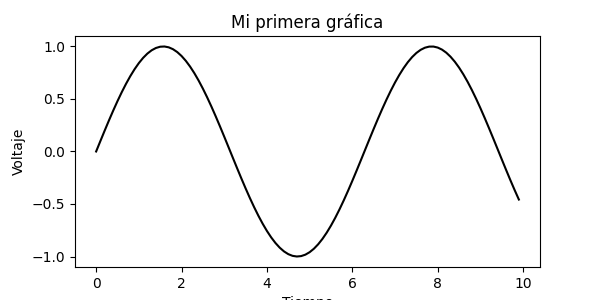

In [27]:
# Gráfico básico
x = np.arange(0, 10, 0.1)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, y, color='black')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Voltaje')
ax.set_title('Mi primera gráfica')
plt.show()

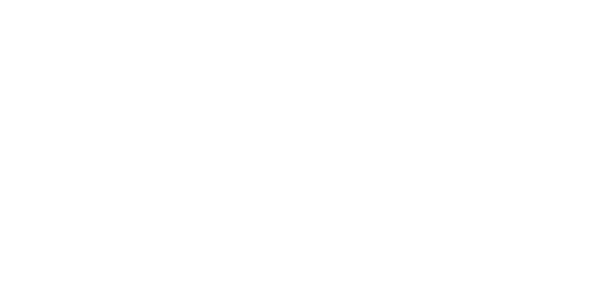

In [28]:
# Personalizar líneas
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, np.sin(x), color='black', linewidth=2, label='sin(x)')
ax.plot(x, np.cos(x), color='red', linewidth=1, linestyle='dashed', label='cos(x)')
ax.axhline(0, color='gray', alpha=0.3)        # línea horizontal
ax.axvline(np.pi, color='blue', linewidth=0.5) # línea vertical
ax.legend(fontsize=8)
ax.set_xlabel('x')
fig.tight_layout()
plt.show()

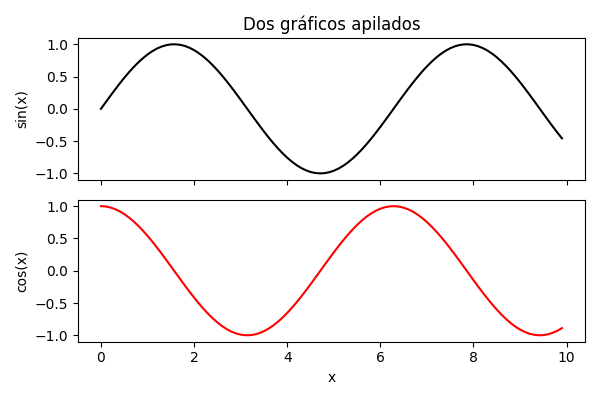

In [29]:
# Subplots: múltiples gráficos apilados
fig, axs = plt.subplots(2, figsize=(6, 4), sharex=True)

axs[0].plot(x, np.sin(x), color='black')
axs[0].set_ylabel('sin(x)')
axs[0].set_title('Dos gráficos apilados')

axs[1].plot(x, np.cos(x), color='red')
axs[1].set_ylabel('cos(x)')
axs[1].set_xlabel('x')

fig.tight_layout()
plt.show()

¿Dónde aparece?

```python
fig, axs = plt.subplots(2, figsize=(4, 4), sharex=True)
axs[0].plot(x, trace, color='black')
axs[0].set_ylabel('Voltage (mV)')
axs[1].plot(x, dtrace, color='black')
axs[1].axvline(peak_time, color='blue')
fig.tight_layout()
```

---

## 10. Las dos funciones clave: `np.gradient` y `np.polyfit`

### 10.1 `np.gradient`: derivada numérica

`np.gradient(y, dx)` calcula la derivada de `y`, donde `dx` es el paso entre puntos.

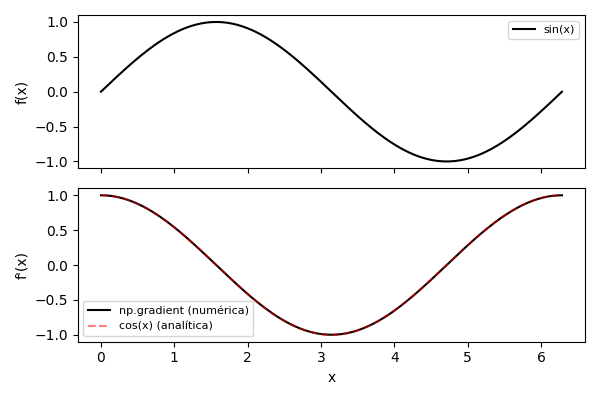

In [30]:
x = np.linspace(0, 2 * np.pi, 200)
dx = x[1] - x[0]

y = np.sin(x)
dy = np.gradient(y, dx)

fig, axs = plt.subplots(2, figsize=(6, 4), sharex=True)
axs[0].plot(x, y, 'black', label='sin(x)')
axs[0].set_ylabel('f(x)')
axs[0].legend(fontsize=8)

axs[1].plot(x, dy, 'black', label='np.gradient (numérica)')
axs[1].plot(x, np.cos(x), 'r--', alpha=0.5, label='cos(x) (analítica)')
axs[1].set_ylabel("f'(x)")
axs[1].set_xlabel('x')
axs[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

### 10.2 `np.polyfit`: ajustar una recta (regresión lineal)

`np.polyfit(x, y, grado)` ajusta un polinomio. Con `grado=1` ajusta una recta: y = mx + b.

Pendiente: 2.50 (real: 3.0)
Intercepto: 13.87 (real: 10.0)


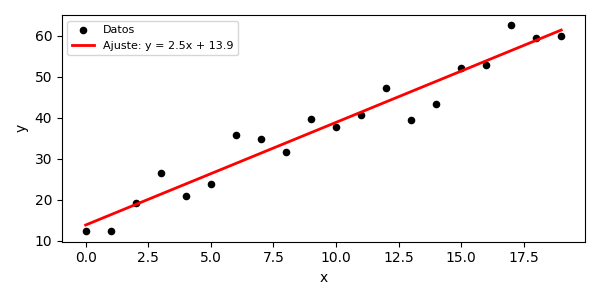

In [31]:
np.random.seed(42)
x_datos = np.arange(20)
y_datos = 3.0 * x_datos + 10 + np.random.randn(20) * 5

pendiente, intercepto = np.polyfit(x_datos, y_datos, 1)
print(f"Pendiente: {pendiente:.2f} (real: 3.0)")
print(f"Intercepto: {intercepto:.2f} (real: 10.0)")

recta = pendiente * x_datos + intercepto

fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(x_datos, y_datos, color='black', s=20, label='Datos')
ax.plot(x_datos, recta, color='red', linewidth=2,
        label=f'Ajuste: y = {pendiente:.1f}x + {intercepto:.1f}')
ax.legend(fontsize=8)
ax.set_xlabel('x')
ax.set_ylabel('y')
fig.tight_layout()
plt.show()

---

## 11. Juntando todo: construir la función paso a paso

Ahora ya conoces cada ingrediente. Vamos a construir la función completa.

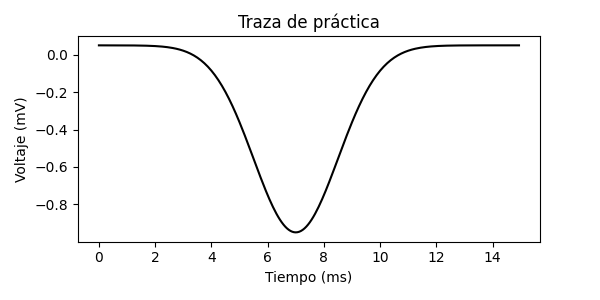

In [41]:
# Traza falsa tipo fEPSP para practicar
sr = 16000
dt = 1.0 / sr
t = np.arange(0, 0.015, dt)
t_ms = t * 1000

np.random.seed(42)
trace = -0.001 * np.exp(-((t_ms - 7) ** 2) / (2 * 1.5 ** 2)) + 0.00005

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t_ms, trace * 1000, color='black')
ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel('Voltaje (mV)')
ax.set_title('Traza de práctica')
fig.tight_layout()
plt.show()

### Paso 1: Calcular la derivada y encontrar el pico

In [42]:
dtrace = np.gradient(trace, dt)
peak_ix = np.argmin(dtrace)
print(f"Índice del mínimo de la derivada: {peak_ix}")
print(f"Tiempo: {peak_ix * dt * 1000:.2f} ms")

Índice del mínimo de la derivada: 88
Tiempo: 5.50 ms


### Paso 2: Definir la ventana alrededor del pico

In [43]:
samp_window = 10
left = peak_ix - samp_window
right = peak_ix + samp_window
print(f"Ventana: muestra {left} a {right} ({right - left} muestras)")

Ventana: muestra 78 a 98 (20 muestras)


### Paso 3: Regresión lineal en la ventana

In [44]:
x_fit = np.arange(left, right)
y_fit = trace[left:right]
slope_samp, intercept = np.polyfit(x_fit, y_fit, 1)
slope_V_sec = slope_samp * sr
print(f"Pendiente: {slope_V_sec:.4f} V/s")

Pendiente: -0.3908 V/s


### Paso 4: Visualizar el resultado

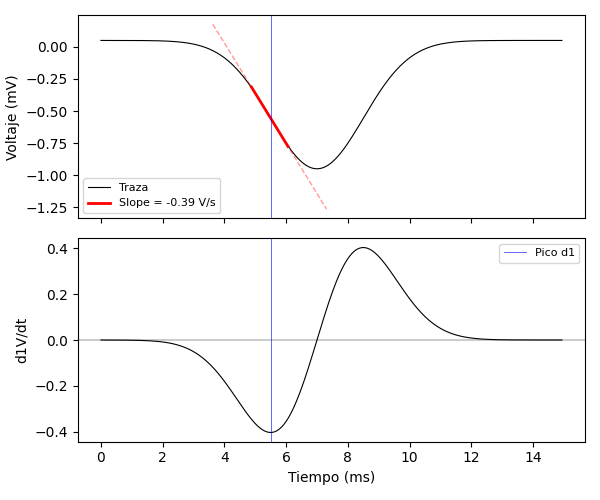

In [46]:
fit_line = slope_samp * x_fit + intercept
x_ext = np.arange(left - 20, right + 20)
fit_ext = slope_samp * x_ext + intercept

fig, axs = plt.subplots(2, figsize=(6, 5), sharex=True)

axs[0].plot(t_ms, trace * 1000, color='black', linewidth=0.8, label='Traza')
axs[0].plot(x_fit * dt * 1000, fit_line * 1000, color='red', linewidth=2,
            label=f'Slope = {slope_V_sec:.2f} V/s')
axs[0].plot(x_ext * dt * 1000, fit_ext * 1000, color='red', linewidth=1,
            linestyle='dashed', alpha=0.4)
axs[0].axvline(peak_ix * dt * 1000, color='blue', linewidth=0.7, alpha=0.6)
axs[0].set_ylabel('Voltaje (mV)')
axs[0].legend(fontsize=8)

axs[1].plot(t_ms, dtrace, color='black', linewidth=0.8)
axs[1].axvline(peak_ix * dt * 1000, color='blue', linewidth=0.7, alpha=0.6, label='Pico d1')
axs[1].axhline(0, color='black', alpha=0.2)
axs[1].set_ylabel('d1V/dt')
axs[1].set_xlabel('Tiempo (ms)')
axs[1].legend(fontsize=8)

fig.tight_layout()

plt.show()

### Paso 5: Empaquetar todo en una función

In [47]:
def calculate_slope(trace, d=1, sr=16000, samp_window=10):
    """
    Calcula la pendiente del fEPSP.
    
    trace:       array con la traza
    d:           orden de la derivada (1 recomendado)
    sr:          sample rate en Hz
    samp_window: muestras a cada lado del pico
    
    Devuelve: slope en V/s
    """
    dt = 1.0 / sr
    
    dtrace = np.copy(trace)
    for i in range(d):
        dtrace = np.gradient(dtrace, dt)
    
    peak_ix = np.argmin(dtrace)
    left = peak_ix - samp_window
    right = peak_ix + samp_window
    
    x_fit = np.arange(left, right)
    y_fit = trace[left:right]
    slope_samp, intercept = np.polyfit(x_fit, y_fit, 1)
    slope_V_sec = slope_samp * sr
    
    return slope_V_sec


resultado = calculate_slope(trace, d=1, sr=16000, samp_window=10)
print(f"Slope calculado: {resultado:.4f} V/s")

Slope calculado: -0.3908 V/s


Recapitulando:

| Concepto | Ejemplo en el código |
|---|---|
| **Variables** | `dt = 1.0 / sr` |
| **Operaciones** | `slope_V_sec = slope_samp * sr` |
| **Arrays NumPy** | `x_fit = np.arange(left, right)` |
| **Slicing** | `y_fit = trace[left:right]` |
| **Condicionales** | `if group == 'shocked' and mouse_n >= 24:` |
| **Bucles for** | `for i in range(d):` |
| **Funciones** | `def calculate_slope(trace, sr=16000):` |
| **Return** | `return slope_V_sec` |
| **Diccionarios** | `data['dd']['raw'][group]['mouse'][n]` |
| **np.gradient** | Derivada numérica |
| **np.polyfit** | Regresión lineal |
| **Matplotlib** | `axs[0].plot(x, y, color='red')` |

---

### 

Vuelve al notebook "B. Extraer pendiente de fEPSP" — ahora deberías poder leer y modificar el código con confianza.